In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import random
from EMDPM.model_generator import generate_logistic_model, get_adjacency_matrix, create_patient_list
from EMDPM.synthetic_data_generator import generate_synthetic_data
from EMDPM.visualization import * 
from EMDPM.utils import *
from EMDPM.subtyping_em_transformer import SubtypingEM

np.set_printoptions(precision=4)

In [2]:
# data params
n_biomarkers = 3
t_max = 40 # was 20
t_span = np.linspace(0, t_max, 8000)
noise_level = 0.0
n_patients = 150 # was 200
n_patient_obs = 3
n_subtypes = 2 #3,4,5
rng = np.random.RandomState(75)

For subtype data generation: different sets of trajectories are generated for each subtype. 
- K is held constant for each subtype
- f and scalar_K are different for each subtype

- removed variablity in time point, now they are in intervals of integer years to mirror ppmi data.
- only one copy of beta now generated instead of three identical copies.

SUBTYPE 0:
f: [0.  0.  0.3]
a = 3.2757608804769824, b = 0.6596422758944243


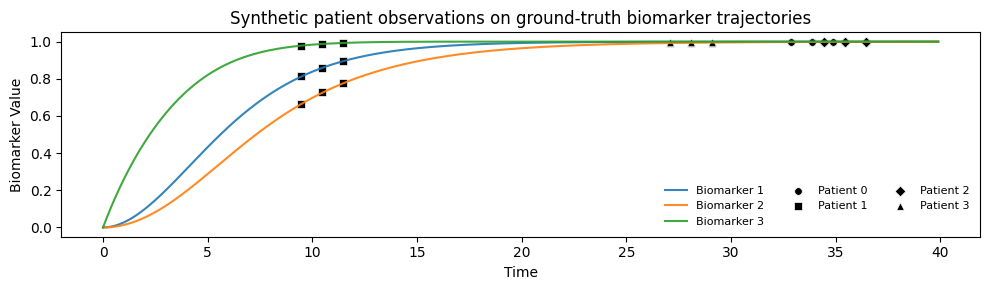

SUBTYPE 1:
f: [0.2 0.  0. ]
a = 2.243319199025421, b = 8.1898722071885


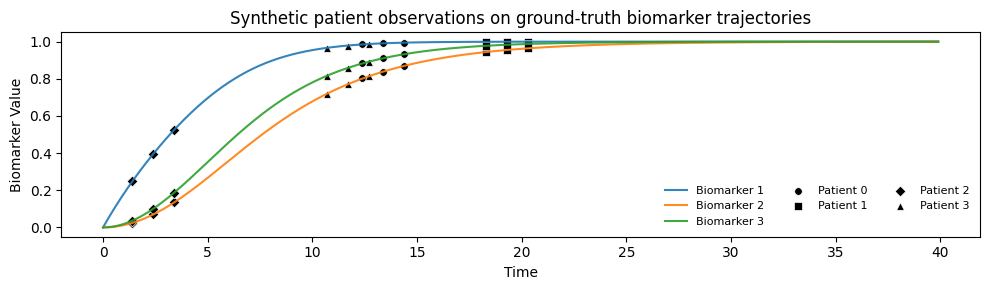

In [3]:
K = get_adjacency_matrix("random_offdiag", n_biomarkers, np.random.RandomState(75))

scalar_K_list = [0.2, 0.2]
f_list = []
for _ in range(n_subtypes):
    f_list.append(rng.gamma(shape=2, scale=0.005, size=n_biomarkers))

f_list = [np.array([0.0, 0.0, 0.3]), np.array([0.2, 0.0, 0.0])]

X = []
y = []

for subtype in range(n_subtypes):
    print(f"SUBTYPE {subtype}:")
    
    
    t, x_true, K, x0, f, scalar_K  = generate_logistic_model(n_biomarkers = n_biomarkers,
                                                             scalar_K = scalar_K_list[subtype],
                                                             t_max = t_max,
                                                             K = K,
                                                             f = f_list[subtype])

    print(f"f: {f}")
    
    df, cog_a, cog_b = generate_synthetic_data(
        n_biomarkers = n_biomarkers,
        t_max = t_max, 
        noise_level = noise_level,
        n_patients = n_patients,
        n_patient_obs = n_patient_obs,
        x_true=x_true, 
        t=t,
        rng = np.random.RandomState(75 + subtype),
    )

    plot_true_observations(df, t, x_true, patient_idx=[0,1,2,3])

    biomarker_cols = [col for col in df.columns if col.startswith("biomarker_")]

    X_obs = df[biomarker_cols].values   # (n_obs, n_biomarkers)
    dt = df["dt"].values                # (n_obs,)
    ids = df["patient_id"].values + subtype * n_patients # (n_obs,),  `+ subtype * n_patients` is for ensuring all ids are unique
    cog = df["cognitive_score"].values  # (n_obs,)
    beta_true = df["beta_true"].values  # (n_obs)
    
    #print(f"dt shape: {dt.shape}\nids shape: {ids.shape}\ncog shape: {cog.shape}\nbeta shape: {beta_true.shape}")
    #print(beta_true)
    
    X_subtype = create_patient_list(X_obs, ids, dt, cog, initial_beta=None)
    
    for p in X_subtype: # tag each patient with true subtype for later eval
        p["subtype_true"] = int(subtype)
    X += X_subtype # pythonic concatenate list syntactic sugar
    
    y.append(beta_true[::n_patient_obs] )
    #  print(beta_true[::n_patient_obs][0:10])
    
X = np.asarray(X)
y = np.concatenate(y)

# print(len(X))
# print(len(y))#, y)
# print(y)

In [4]:
# Initialize beta from clinical scores using the new generalized function
print("Initializing beta from clinical scores...")

# Extract data for beta initialization
all_dt = np.concatenate([p["dt"] for p in X])
all_cog = np.concatenate([p["cog"] for p in X])
all_ids_array = np.concatenate([[p["id"]] * len(p["dt"]) for p in X])

# Use the new function to initialize beta
initial_beta, pid_to_beta, result = fit_mixedlm_beta_from_clinical(
    ids=all_ids_array,
    dt=all_dt,
    cog=all_cog,
    t_max=t_max,
    verbose=True,
    rng=np.random.default_rng(75)
)

# Store true beta values for later comparison
# The y array contains true beta values (one per patient, in order)
# We need to map them to the patient IDs
unique_ids = np.unique([p["id"] for p in X])
beta_true_array = y  # y was created in cell 3 with beta_true[::n_patient_obs] for each subtype
        
print(f"Initialized beta for {len(initial_beta)} patients")
print(f"Beta range: [{np.min(initial_beta):.2f}, {np.max(initial_beta):.2f}]")
print(f"True beta range: [{np.min(beta_true_array):.2f}, {np.max(beta_true_array):.2f}]")


Initializing beta from clinical scores...
β_init summary: count    300.000000
mean      20.222086
std       11.624986
min        0.000000
25%       10.264950
50%       19.501667
75%       29.270905
max       40.000000
dtype: float64
Initialized beta for 300 patients
Beta range: [0.00, 40.00]
True beta range: [0.07, 36.94]


## fit() Call

The SubtypingEM algorithm performs:
1. Global s parameter estimation
2. Cluster assignment (hard assignment for now)
3. Cluster-level f and scalar_K estimation
4. Patient-level beta estimation

Fitting SubtypingEM...


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [04:29<00:00,  5.40s/it]



Fitting complete!


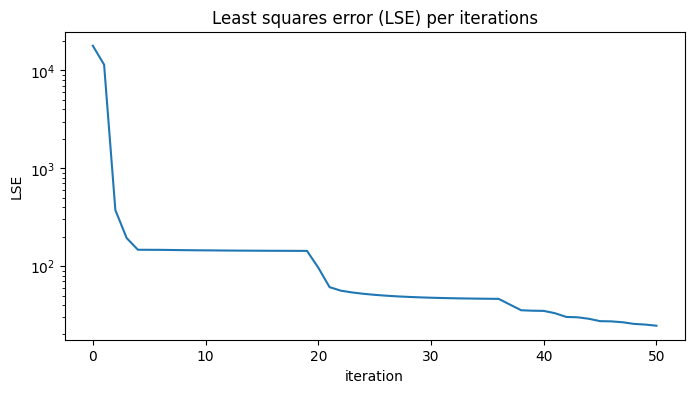

In [5]:
f_init = initialize_f_eigen(K=K)
if isinstance(f_init, list):
    f_init = f_init[0]

# Add initial_beta to patient data (from cell 4)
unique_ids = np.unique([p["id"] for p in X])
id_to_beta_idx = {pid: idx for idx, pid in enumerate(unique_ids)}
for p in X:
    p["initial_beta"] = initial_beta[id_to_beta_idx[p["id"]]]

subtyping_em = SubtypingEM(
    K=K,
    initial_f=f_init,
    n_subtypes=n_subtypes,
    jac_toggle=True,
    max_iter=50,
    t_max=t_max,
    step=0.01,
    epsilon=1e-1,
    lambda_f=0.1,
    lambda_cog=0.01,
    lambda_scalar=0.05,
    verbose=1,
    rng=np.random.default_rng(75)
)

print("Fitting SubtypingEM...")
subtyping_em.fit(X)
print("\nFitting complete!")

# Plot LSE history
plot_lse(subtyping_em.lse_history)

In [6]:
# Print cluster parameters
for subtype in range(n_subtypes):
    print(f"\nCluster {subtype}:")
    print(f"  f: {subtyping_em.cluster_f[subtype]}")
    print(f"  scalar_K: {subtyping_em.cluster_scalar_K[subtype]:.6f}")

print(f"\nGlobal s: {subtyping_em.final_s}")
print(f"\nFinal LSE: {subtyping_em.lse_history[-1]:.6f}")

# Store for later use
final_s = subtyping_em.final_s.copy()



Cluster 0:
  f: [0.     0.     0.0123]
  scalar_K: 0.287295

Cluster 1:
  f: [0.0015 0.     0.0011]
  scalar_K: 0.337178

Global s: [0.9787 0.9284 0.9723]

Final LSE: 24.548649


/home/dsemchin/Progression_models_simulations/EMDPM/visualization.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


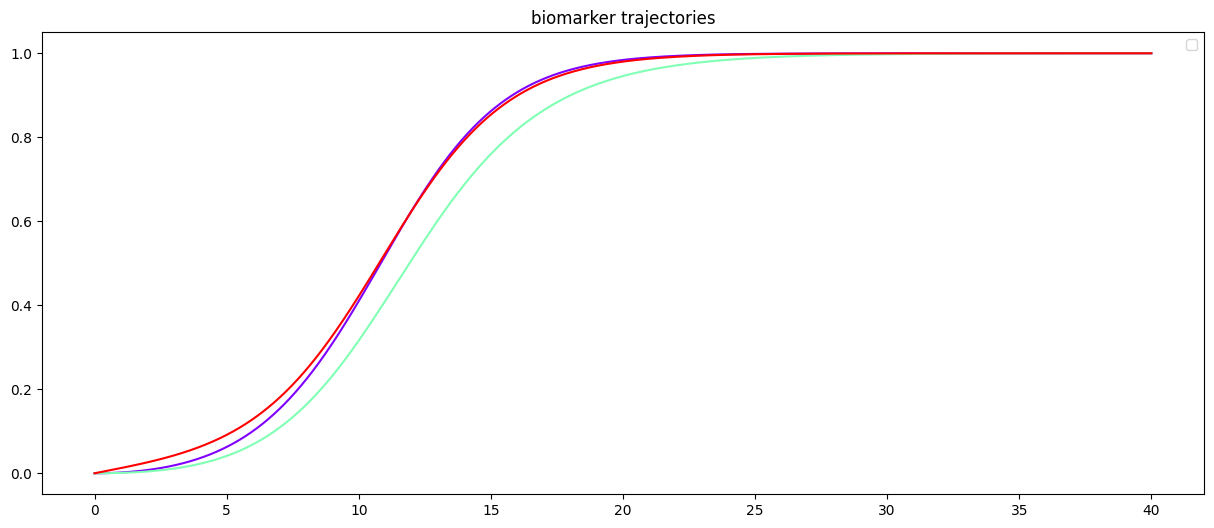

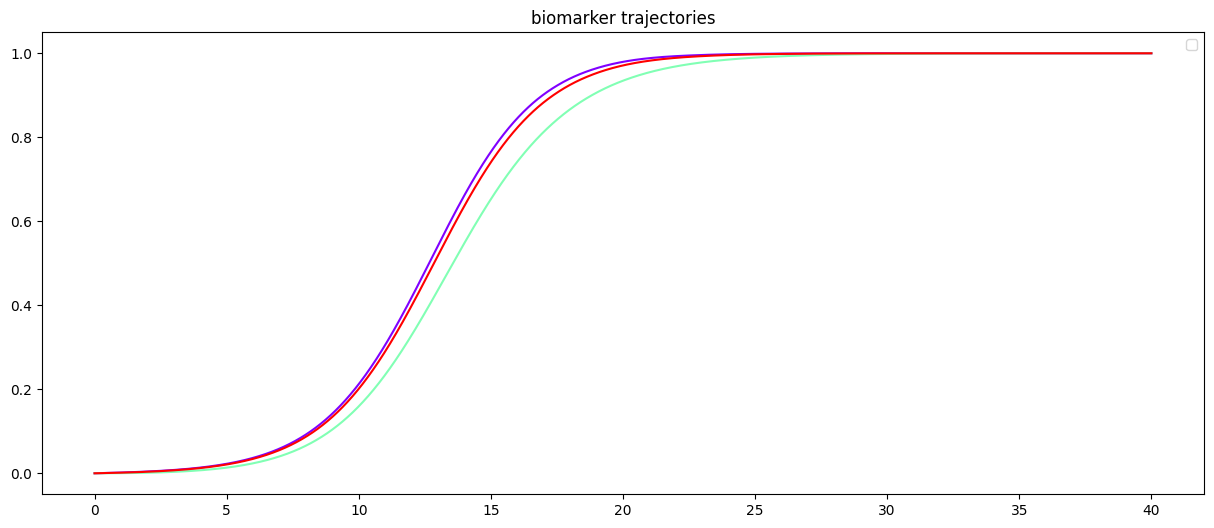

In [7]:

# Plot cluster trajectories

for subtype in range(n_subtypes):
    f_cluster = subtyping_em.cluster_f[subtype]
    scalar_K_cluster = subtyping_em.cluster_scalar_K[subtype]
    cluster_trajectory = solve_system(
        x0=np.zeros(n_biomarkers),
        f=f_cluster,
        K=K,
        t_span=t_span,
        scalar_K=scalar_K_cluster
    )
    plot_biomarker_trajectories(
        biom_trajectories=cluster_trajectory,
        t_span=t_span,
        n_biomarkers=n_biomarkers,
    )

## Cluster Assignment Evaluation

evaluate how well the algorithm recovered the true subtypes.

In [8]:

from sklearn.metrics import adjusted_rand_score, confusion_matrix, classification_report

assignments_pred = subtyping_em.final_assignments
assignments_true = np.array([p["subtype_true"] for p in X])

print("=== BEFORE LABEL MATCHING ===")
print(f"True assignments distribution: {np.bincount(assignments_true)}")
print(f"Predicted assignments distribution: {np.bincount(assignments_pred)}")

ari_before = adjusted_rand_score(assignments_true, assignments_pred)
print(f"\nAdjusted Rand Index (before matching): {ari_before:.4f}")

print("\nConfusion Matrix (before matching):")
print(confusion_matrix(assignments_true, assignments_pred))

# Check if label matching was applied
if hasattr(subtyping_em, 'label_mapping_applied') and subtyping_em.label_mapping_applied:
    print("\n=== AFTER LABEL MATCHING ===")
    assignments_matched = subtyping_em.final_assignments_matched
    print(f"Matched assignments distribution: {np.bincount(assignments_matched)}")
    
    ari_after = adjusted_rand_score(assignments_true, assignments_matched)
    print(f"\nAdjusted Rand Index (after matching): {ari_after:.4f}")
    
    print("\nConfusion Matrix (after matching):")
    print(confusion_matrix(assignments_true, assignments_matched))
    
    print("\nClassification Report (after matching):")
    print(classification_report(assignments_true, assignments_matched))
    
    # Use matched assignments for evaluation
    assignments_pred = assignments_matched
else:
    print("\nLabel matching was not applied (no subtype_true found or matching failed)")
    print("\nClassification Report (before matching):")
    print(classification_report(assignments_true, assignments_pred))

for i, patient in enumerate(X):
    patient["subtype_pred"] = int(assignments_pred[i])
    patient["beta_pred"] = float(subtyping_em.beta_history[i, -1])

=== BEFORE LABEL MATCHING ===
True assignments distribution: [150 150]
Predicted assignments distribution: [ 75 225]

Adjusted Rand Index (before matching): 0.0171

Confusion Matrix (before matching):
[[ 27 123]
 [ 48 102]]

=== AFTER LABEL MATCHING ===
Matched assignments distribution: [225  75]

Adjusted Rand Index (after matching): 0.0171

Confusion Matrix (after matching):
[[123  27]
 [102  48]]

Classification Report (after matching):
              precision    recall  f1-score   support

           0       0.55      0.82      0.66       150
           1       0.64      0.32      0.43       150

    accuracy                           0.57       300
   macro avg       0.59      0.57      0.54       300
weighted avg       0.59      0.57      0.54       300



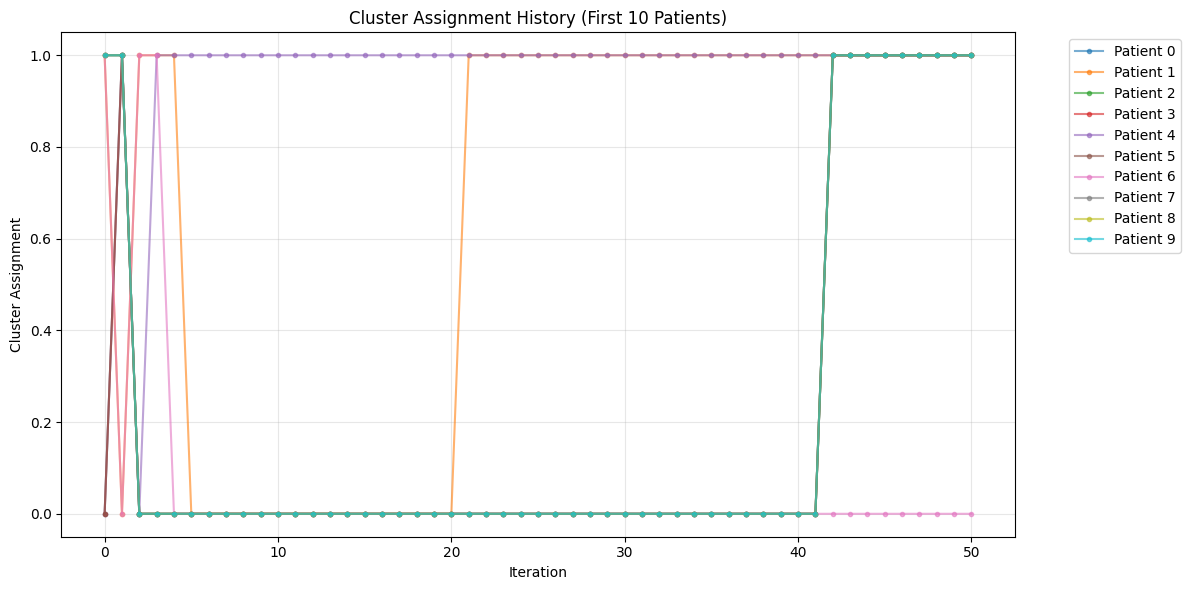

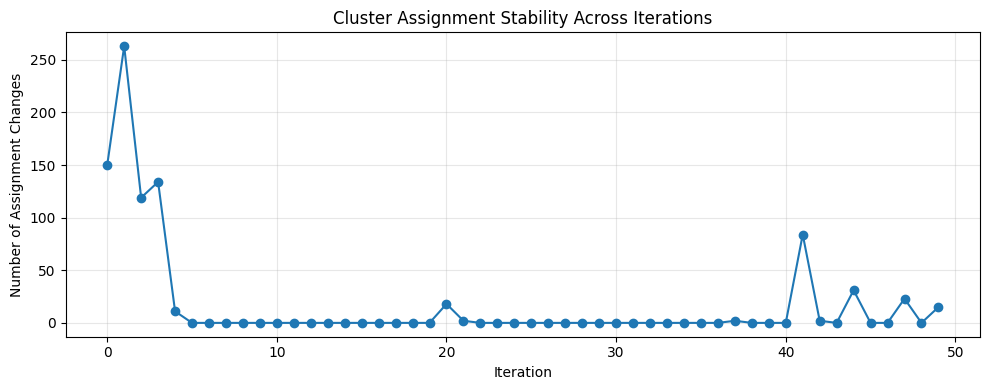

In [9]:
# plot assignment history to see convergence
import matplotlib.pyplot as plt

if hasattr(subtyping_em, 'assignment_history'):
    plt.figure(figsize=(12, 6))
    for patient_idx in range(min(10, len(X))):  # Plot first 10 patients
        plt.plot(subtyping_em.assignment_history[patient_idx, :], 
                marker='o', markersize=3, alpha=0.6, label=f'Patient {patient_idx}')
    plt.xlabel('Iteration')
    plt.ylabel('Cluster Assignment')
    plt.title('Cluster Assignment History (First 10 Patients)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# plot assignment stability
assignment_changes = np.sum(np.diff(subtyping_em.assignment_history, axis=1) != 0, axis=0)
plt.figure(figsize=(10, 4))
plt.plot(assignment_changes, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Number of Assignment Changes')
plt.title('Cluster Assignment Stability Across Iterations')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Compare true vs predicted cluster parameters
print("\nTrue Parameters (from data generation):")
for subtype in range(n_subtypes):
    print(f"\nSubtype {subtype}:")
    print(f"  f: {f_list[subtype]}")
    print(f"  scalar_K: {scalar_K_list[subtype]}")

print("\nPredicted Parameters (from SubtypingEM):")
for subtype in range(n_subtypes):
    print(f"\nSubtype {subtype}:")
    print(f"  f: {subtyping_em.cluster_f[subtype]}")
    print(f"  scalar_K: {subtyping_em.cluster_scalar_K[subtype]:.6f}")

print(f"\nGlobal s: {subtyping_em.final_s}")


True Parameters (from data generation):

Subtype 0:
  f: [0.  0.  0.3]
  scalar_K: 0.2

Subtype 1:
  f: [0.2 0.  0. ]
  scalar_K: 0.2

Predicted Parameters (from SubtypingEM):

Subtype 0:
  f: [0.     0.     0.0123]
  scalar_K: 0.287295

Subtype 1:
  f: [0.0015 0.     0.0011]
  scalar_K: 0.337178

Global s: [0.9787 0.9284 0.9723]


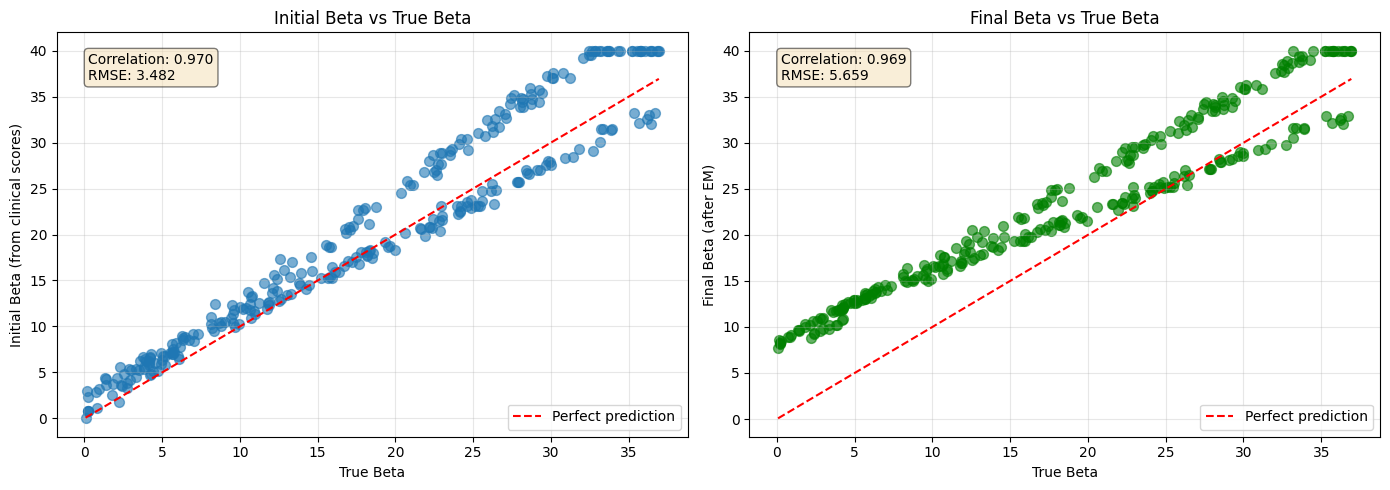


=== Beta Comparison Summary ===
Initial Beta:
  Mean: 20.222, Std: 11.606
  Range: [0.000, 40.000]

True Beta:
  Mean: 18.242, Std: 10.850
  Range: [0.072, 36.938]

Final Beta:
  Mean: 23.045, Std: 9.186
  Range: [7.729, 40.000]

Initial Beta Error:
  RMSE: 3.482, Correlation: 0.970

Final Beta Error:
  RMSE: 5.659, Correlation: 0.969
  Improvement: -2.176 (-62.5% reduction)


In [11]:
# Plot initial beta vs true beta
import matplotlib.pyplot as plt

# Get initial beta (from clinical scores) - already stored in patient dicts
beta_init_array = np.array([p.get("initial_beta", np.nan) for p in X])
if np.any(np.isnan(beta_init_array)):
    # Fallback: use the initial_beta array directly
    beta_init_array = initial_beta

# Get final beta
beta_final_array = subtyping_em.beta_history[:, -1]

# True beta is already stored in beta_true_array from cell 4

# Create comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Initial beta vs True beta
axes[0].scatter(beta_true_array, beta_init_array, alpha=0.6, s=50)
axes[0].plot([beta_true_array.min(), beta_true_array.max()], 
             [beta_true_array.min(), beta_true_array.max()], 
             'r--', label='Perfect prediction')
axes[0].set_xlabel('True Beta')
axes[0].set_ylabel('Initial Beta (from clinical scores)')
axes[0].set_title('Initial Beta vs True Beta')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Calculate correlation
corr_init = np.corrcoef(beta_true_array, beta_init_array)[0, 1]
rmse_init = np.sqrt(np.mean((beta_true_array - beta_init_array)**2))
axes[0].text(0.05, 0.95, f'Correlation: {corr_init:.3f}\nRMSE: {rmse_init:.3f}', 
             transform=axes[0].transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Final beta vs True beta
axes[1].scatter(beta_true_array, beta_final_array, alpha=0.6, s=50, c='green')
axes[1].plot([beta_true_array.min(), beta_true_array.max()], 
             [beta_true_array.min(), beta_true_array.max()], 
             'r--', label='Perfect prediction')
axes[1].set_xlabel('True Beta')
axes[1].set_ylabel('Final Beta (after EM)')
axes[1].set_title('Final Beta vs True Beta')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Calculate correlation
corr_final = np.corrcoef(beta_true_array, beta_final_array)[0, 1]
rmse_final = np.sqrt(np.mean((beta_true_array - beta_final_array)**2))
axes[1].text(0.05, 0.95, f'Correlation: {corr_final:.3f}\nRMSE: {rmse_final:.3f}', 
             transform=axes[1].transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Beta Comparison Summary ===")
print(f"Initial Beta:")
print(f"  Mean: {np.mean(beta_init_array):.3f}, Std: {np.std(beta_init_array):.3f}")
print(f"  Range: [{np.min(beta_init_array):.3f}, {np.max(beta_init_array):.3f}]")
print(f"\nTrue Beta:")
print(f"  Mean: {np.mean(beta_true_array):.3f}, Std: {np.std(beta_true_array):.3f}")
print(f"  Range: [{np.min(beta_true_array):.3f}, {np.max(beta_true_array):.3f}]")
print(f"\nFinal Beta:")
print(f"  Mean: {np.mean(beta_final_array):.3f}, Std: {np.std(beta_final_array):.3f}")
print(f"  Range: [{np.min(beta_final_array):.3f}, {np.max(beta_final_array):.3f}]")
print(f"\nInitial Beta Error:")
print(f"  RMSE: {rmse_init:.3f}, Correlation: {corr_init:.3f}")
print(f"\nFinal Beta Error:")
print(f"  RMSE: {rmse_final:.3f}, Correlation: {corr_final:.3f}")
print(f"  Improvement: {rmse_init - rmse_final:.3f} ({(1 - rmse_final/rmse_init)*100:.1f}% reduction)")


In [12]:
print(f"\nTotal patients: {len(X)}")
print(f"Number of subtypes: {n_subtypes}")
print(f"Final LSE: {subtyping_em.lse_history[-1]:.6f}")
print(f"Initial LSE: {subtyping_em.lse_history[0]:.6f}")
print(f"LSE improvement: {subtyping_em.lse_history[0] - subtyping_em.lse_history[-1]:.6f}")

# Cluster sizes
print("\nCluster sizes (predicted):")
for subtype in range(n_subtypes):
    size = np.sum(assignments_pred == subtype)
    print(f"  Cluster {subtype}: {size} patients ({100*size/len(X):.1f}%)")

for subtype in range(n_subtypes):
    # Match predicted cluster to true cluster (simple matching for now)
    # In practice, you'd need to handle label permutation
    f_true = f_list[subtype]
    f_pred = subtyping_em.cluster_f[subtype]
    scalar_K_true = scalar_K_list[subtype]
    scalar_K_pred = subtyping_em.cluster_scalar_K[subtype]
    
    f_error = np.mean(np.abs(f_true - f_pred))
    scalar_K_error = np.abs(scalar_K_true - scalar_K_pred)
    
    print(f"\nSubtype {subtype}:")
    print(f"  Mean |f_true - f_pred|: {f_error:.6f}")
    print(f"  |scalar_K_true - scalar_K_pred|: {scalar_K_error:.6f}")



Total patients: 300
Number of subtypes: 2
Final LSE: 24.548649
Initial LSE: 17907.945456
LSE improvement: 17883.396807

Cluster sizes (predicted):
  Cluster 0: 225 patients (75.0%)
  Cluster 1: 75 patients (25.0%)

Subtype 0:
  Mean |f_true - f_pred|: 0.095900
  |scalar_K_true - scalar_K_pred|: 0.087295

Subtype 1:
  Mean |f_true - f_pred|: 0.066552
  |scalar_K_true - scalar_K_pred|: 0.137178


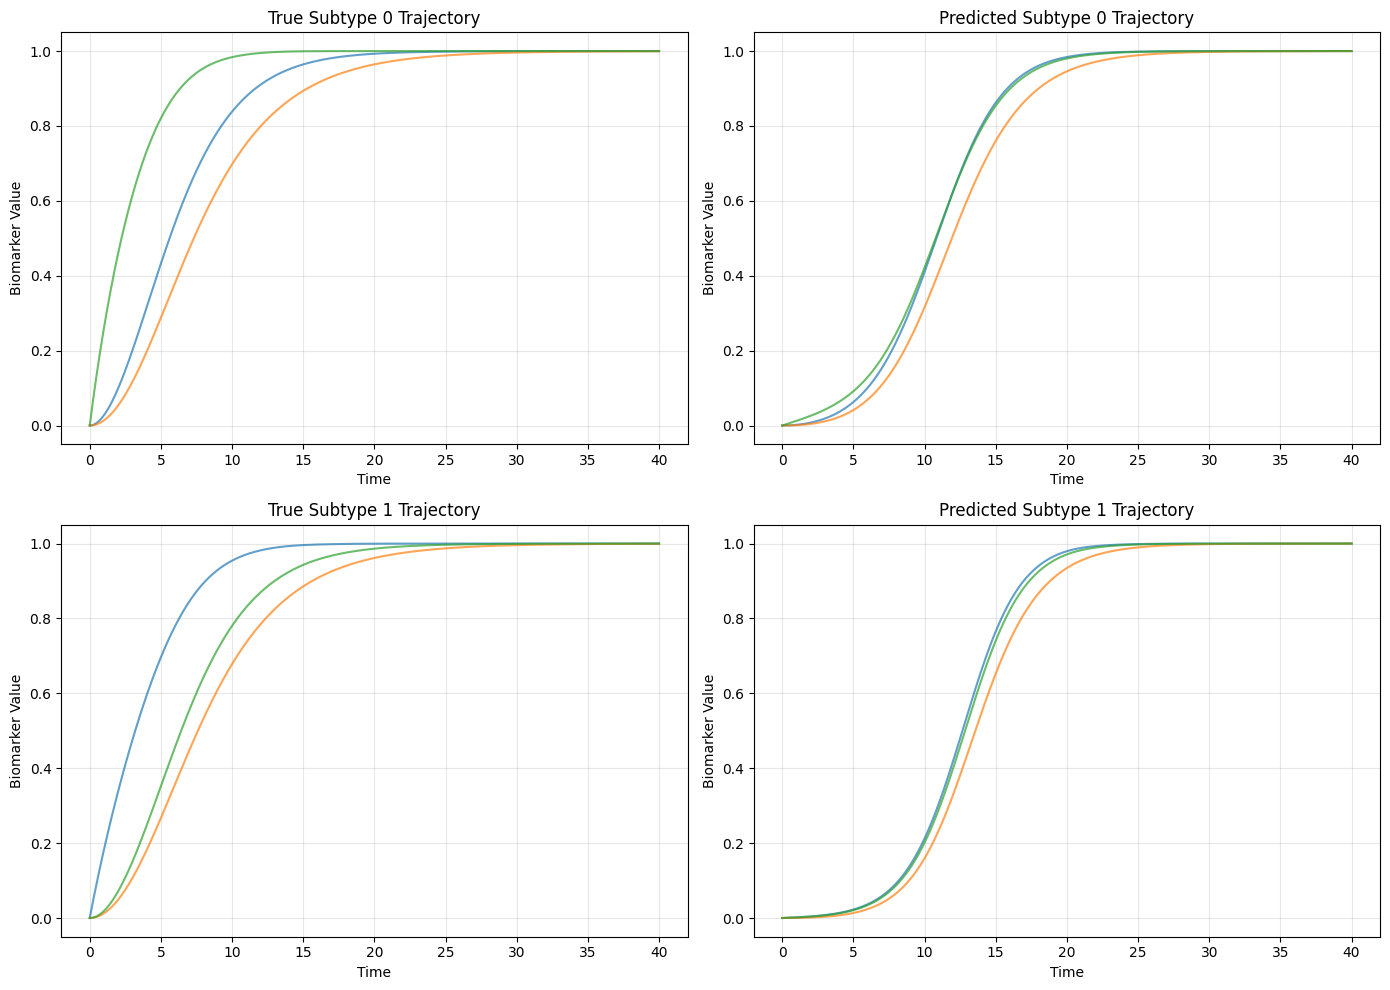

In [13]:
fig, axes = plt.subplots(n_subtypes, 2, figsize=(14, 5*n_subtypes))

for subtype in range(n_subtypes):
    # True trajectory
    f_true = f_list[subtype]
    scalar_K_true = scalar_K_list[subtype]
    trajectory_true = solve_system(
        x0=np.zeros(n_biomarkers),
        f=f_true,
        K=K,
        t_span=t_span,
        scalar_K=scalar_K_true
    )
    
    # Predicted trajectory
    f_pred = subtyping_em.cluster_f[subtype]
    scalar_K_pred = subtyping_em.cluster_scalar_K[subtype]
    trajectory_pred = solve_system(
        x0=np.zeros(n_biomarkers),
        f=f_pred,
        K=K,
        t_span=t_span,
        scalar_K=scalar_K_pred
    )
    
    # Plot true
    for b in range(n_biomarkers):
        axes[subtype, 0].plot(t_span, trajectory_true[b], label=f'Biomarker {b}', alpha=0.7)
    axes[subtype, 0].set_title(f'True Subtype {subtype} Trajectory')
    axes[subtype, 0].set_xlabel('Time')
    axes[subtype, 0].set_ylabel('Biomarker Value')
    axes[subtype, 0].grid(True, alpha=0.3)
    
    # Plot predicted
    for b in range(n_biomarkers):
        axes[subtype, 1].plot(t_span, trajectory_pred[b], label=f'Biomarker {b}', alpha=0.7)
    axes[subtype, 1].set_title(f'Predicted Subtype {subtype} Trajectory')
    axes[subtype, 1].set_xlabel('Time')
    axes[subtype, 1].set_ylabel('Biomarker Value')
    axes[subtype, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
